In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [28]:
# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
df = pd.read_csv("/content/drive/MyDrive/dataset/Air_Qualityr.csv")

In [30]:
df.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI,Temperature,Humidity,Wind Speed
0,2023-01-01 00:00:00+00:00,Brasilia,292.0,30.15,1.10,23.0,11.1,15.8,21.158330,17.67,59.35,13.76
1,2023-01-01 01:00:00+00:00,Brasilia,291.0,28.95,1.15,24.0,12.4,17.7,20.825000,3.46,67.51,6.36
2,2023-01-01 02:00:00+00:00,Brasilia,289.0,27.25,1.25,25.0,13.0,18.5,20.474998,25.29,29.30,12.87
3,2023-01-01 03:00:00+00:00,Brasilia,275.0,23.70,1.30,28.0,9.2,13.1,20.074999,23.15,99.97,7.71
4,2023-01-01 04:00:00+00:00,Brasilia,246.0,19.35,1.25,32.0,6.8,9.7,19.324999,16.02,90.28,14.16


Data-Pre_processing 

In [31]:
# Handle Date Feature
df['Date'] = pd.to_datetime(df['Date'])
df['hour']  = df['Date'].dt.hour
df['day']   = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df.drop(columns=['Date'], inplace=True)

In [32]:
df.head()

,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI,Temperature,Humidity,Wind Speed,hour,day,month
0,Brasilia,292.0,30.15,1.10,23.0,11.1,15.8,21.158330,17.67,59.35,13.76,0,1,1
1,Brasilia,291.0,28.95,1.15,24.0,12.4,17.7,20.825000,3.46,67.51,6.36,1,1,1
2,Brasilia,289.0,27.25,1.25,25.0,13.0,18.5,20.474998,25.29,29.30,12.87,2,1,1
3,Brasilia,275.0,23.70,1.30,28.0,9.2,13.1,20.074999,23.15,99.97,7.71,3,1,1
4,Brasilia,246.0,19.35,1.25,32.0,6.8,9.7,19.324999,16.02,90.28,14.16,4,1,1


In [33]:
df.value_counts('City')

,count
City,
Brasilia,8760
Cairo,8760
Dubai,8760
London,8760
New York,8760
Sydney,8760


In [34]:
print(df.columns)

Index(['City', 'CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI', 'Temperature',
       'Humidity', 'Wind Speed', 'hour', 'day', 'month'],
      dtype='object')


In [ ]:
# handle catogerical features 
df = pd.get_dummies(df, columns=['City'],drop_first=True,dtype=int)

In [36]:
df.head()

,CO,NO2,SO2,O3,PM2.5,PM10,AQI,Temperature,Humidity,Wind Speed,hour,day,month,City_Cairo,City_Dubai,City_London,City_New York,City_Sydney
0,292.0,30.15,1.10,23.0,11.1,15.8,21.158330,17.67,59.35,13.76,0,1,1,0,0,0,0,0
1,291.0,28.95,1.15,24.0,12.4,17.7,20.825000,3.46,67.51,6.36,1,1,1,0,0,0,0,0
2,289.0,27.25,1.25,25.0,13.0,18.5,20.474998,25.29,29.30,12.87,2,1,1,0,0,0,0,0
3,275.0,23.70,1.30,28.0,9.2,13.1,20.074999,23.15,99.97,7.71,3,1,1,0,0,0,0,0
4,246.0,19.35,1.25,32.0,6.8,9.7,19.324999,16.02,90.28,14.16,4,1,1,0,0,0,0,0


In [37]:
# check Null values
df.isnull().sum()

,0
CO,0
NO2,0
SO2,0
O3,0
PM2.5,0
PM10,0
AQI,0
Temperature,0
Humidity,0
Wind Speed,0


In [38]:
df.describe()

,CO,NO2,SO2,O3,PM2.5,PM10,AQI,Temperature,Humidity,Wind Speed,hour,day,month,City_Cairo,City_Dubai,City_London,City_New York,City_Sydney
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,273.372565,28.930514,12.051645,55.304433,18.621792,35.505850,41.941352,14.878617,55.071795,10.231229,11.500000,15.720548,6.526027,0.166667,0.166667,0.166667,0.166667,0.166667
std,171.578815,25.473936,14.684127,36.939938,15.897499,41.866614,24.989747,14.434500,25.999024,5.631873,6.922252,8.796331,3.447884,0.372682,0.372682,0.372682,0.372682,0.372682
min,48.000000,0.000000,0.000000,0.000000,0.000000,0.100000,8.000000,-10.000000,10.010000,0.500000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,160.000000,11.100000,2.500000,29.000000,7.100000,11.000000,22.638333,2.240000,32.500000,5.290000,5.750000,8.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,224.000000,22.100000,5.800000,51.000000,13.400000,20.800000,32.400000,14.750000,55.050000,10.260000,11.500000,16.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,335.000000,38.700000,17.300000,74.000000,24.900000,41.700000,61.013332,27.310000,77.442500,15.070000,17.250000,23.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2145.000000,251.900000,200.800000,425.000000,143.400000,550.000000,188.319980,40.000000,99.990000,20.000000,23.000000,31.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


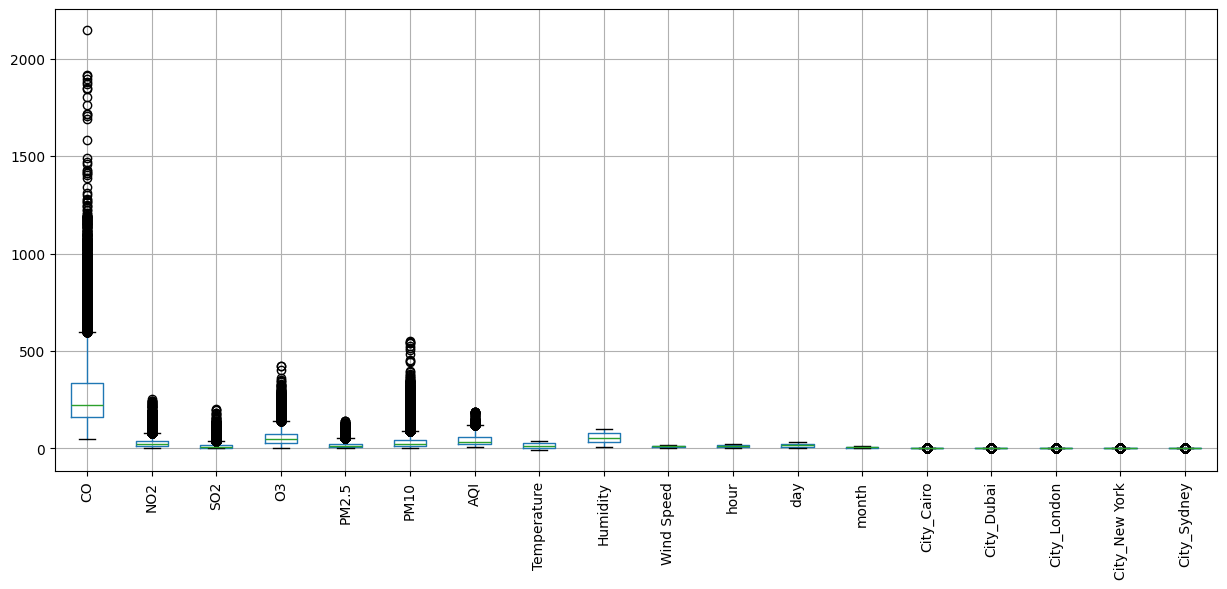

In [39]:
# chack uouliers
df.boxplot(figsize=(15,6))
plt.xticks(rotation=90)
plt.show()

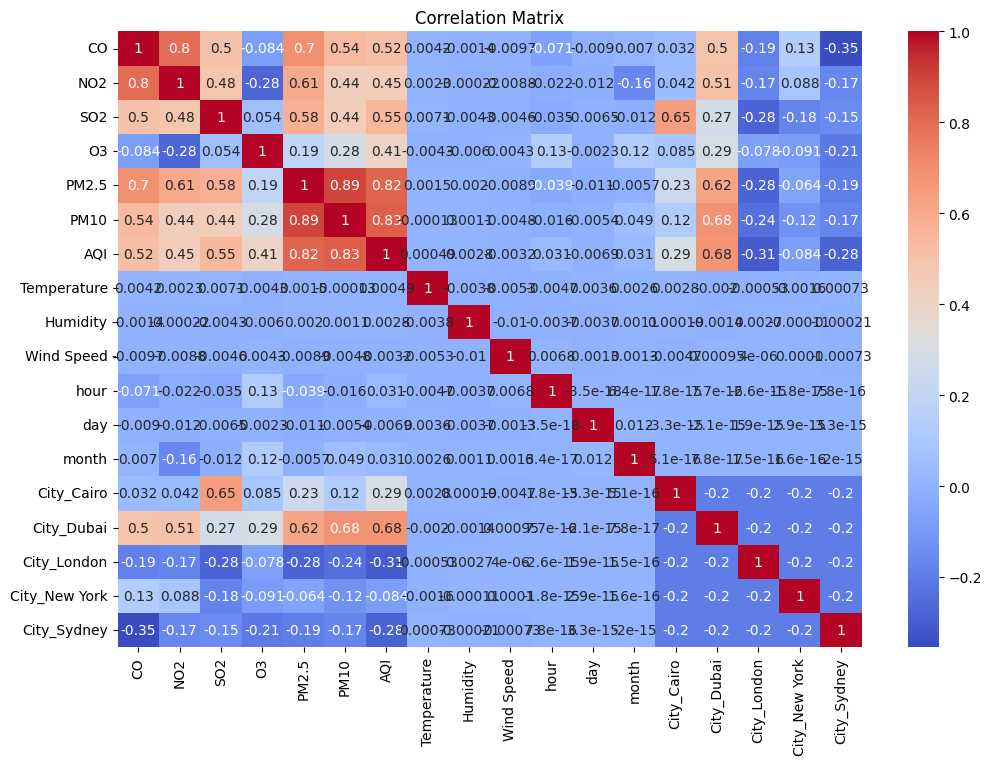

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

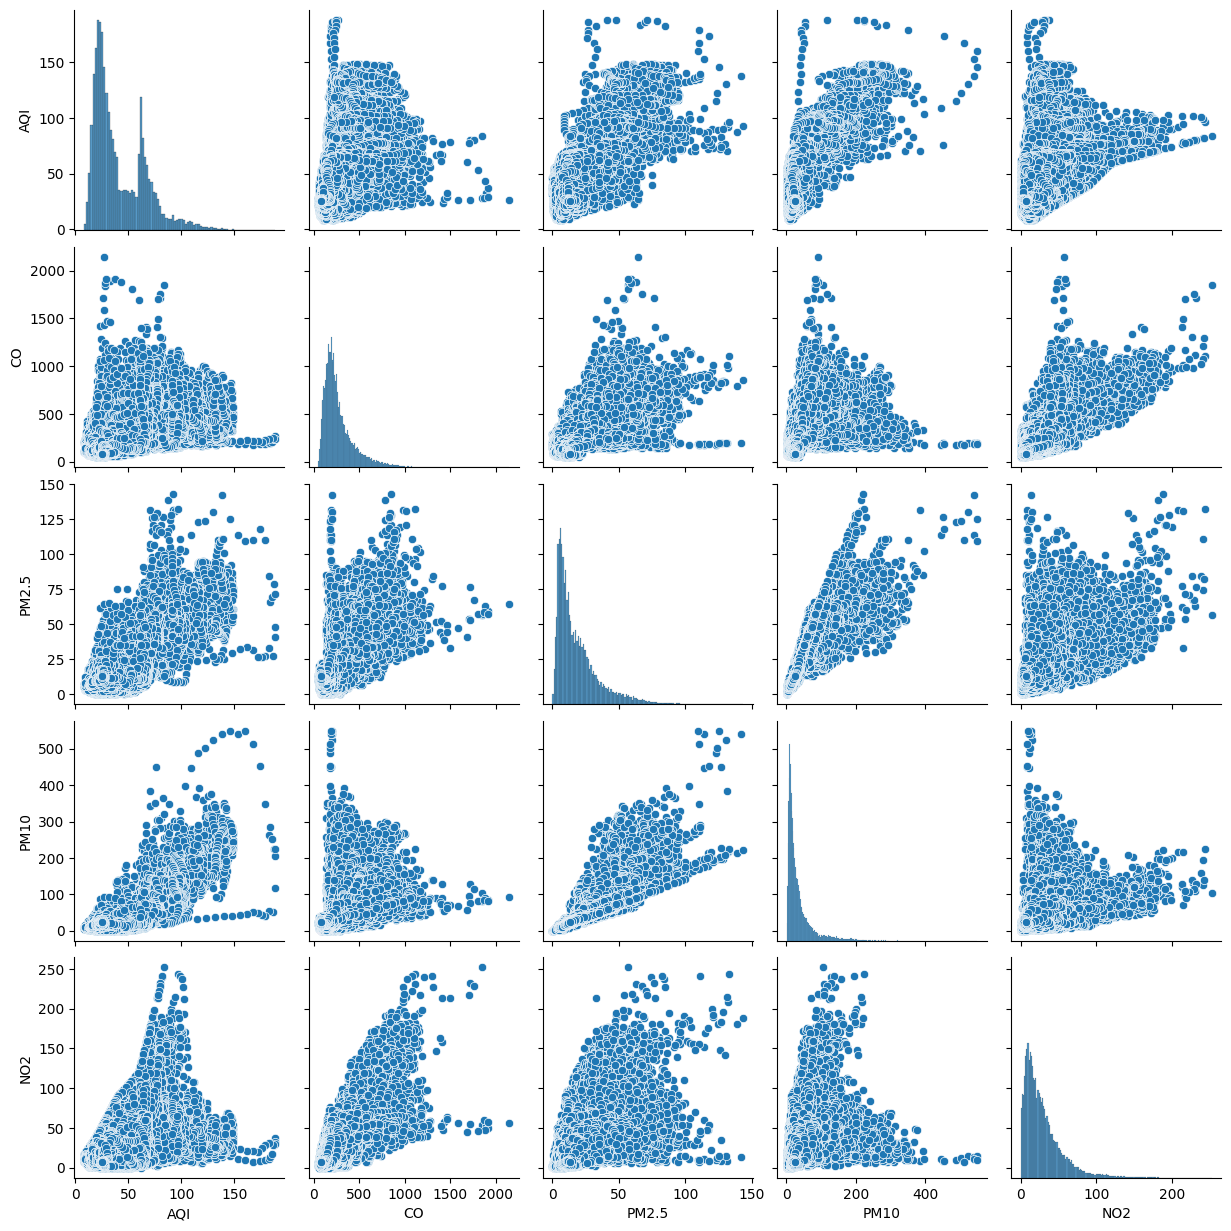

In [41]:
sns.pairplot(df[['AQI', 'CO', 'PM2.5', 'PM10', 'NO2']])
plt.show()

In [42]:
Q1  = df.quantile(0.25)
Q3  = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
print(outliers.sum())

CO               3119
NO2              2369
SO2              2835
O3               1183
PM2.5            2762
PM10             4648
AQI               533
Temperature         0
Humidity            0
Wind Speed          0
hour                0
day                 0
month               0
City_Cairo       8760
City_Dubai       8760
City_London      8760
City_New York    8760
City_Sydney      8760
dtype: int64


Train Test Split and Scaling

In [43]:
x = df.drop(columns=['AQI'])
y = df['AQI']

In [44]:
# Split first, then scale
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
scaler_X = StandardScaler()
x_train_scaled = scaler_X.fit_transform(x_train)
x_test_scaled = scaler_X.transform(x_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

print('x_train shape:', x_train_scaled.shape)
print('y_train shape:', y_train_scaled.shape)


x_train shape: (42048, 17)
y_train shape: (42048, 1)


Build PyTorch Dataset & DataLoaders

In [45]:
# Convert numpy arrays → PyTorch tensors
X_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled,  dtype=torch.float32)   # shape (N, 1)

X_test_t  = torch.tensor(x_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled,   dtype=torch.float32)

# Wrap in TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

# DataLoaders  (validation split: reserve last 20% of training set)
val_size   = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [46]:
x_train_scaled.shape

(42048, 17)

Define The Model

In [47]:
class Model(nn.Module):
    def __init__(self,input_dim:int):
        super().__init__()
        self.net = nn.Sequential(

            nn.Linear(input_dim,256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),# single regression output

        )
    
    def forward(self,x):
        return self.net(x)

INPUT_DIM = x_train_scaled.shape[1]   # 17
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = Model(INPUT_DIM).to(device)
print(model)

Using device: cuda
Model(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [48]:
print(INPUT_DIM)
print(type(INPUT_DIM))

17
<class 'int'>


Train Model

In [49]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

EPOCHS = 50
history = {'loss': [], 'val_loss': [], 'mae': [], 'val_mae': []}

for epoch in range(1, EPOCHS + 1):
    #  Training
    model.train()
    train_loss, train_mae = 0.0, 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
        train_mae  += torch.abs(preds - y_batch).sum().item()

    train_loss /= train_size
    train_mae  /= train_size

    #  Validation 
    model.eval()
    val_loss, val_mae = 0.0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds    = model(X_batch)
            val_loss += criterion(preds, y_batch).item() * len(X_batch)
            val_mae  += torch.abs(preds - y_batch).sum().item()

    val_loss /= val_size
    val_mae  /= val_size

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3}/{EPOCHS}  '
              f'loss={train_loss:.4f}  mae={train_mae:.4f}  '
              f'val_loss={val_loss:.4f}  val_mae={val_mae:.4f}')

Epoch  10/50  loss=0.1070  mae=0.2157  val_loss=0.1001  val_mae=0.2152
Epoch  20/50  loss=0.0949  mae=0.2030  val_loss=0.0931  val_mae=0.2103
Epoch  30/50  loss=0.0881  mae=0.1964  val_loss=0.0911  val_mae=0.1944
Epoch  40/50  loss=0.0818  mae=0.1914  val_loss=0.0829  val_mae=0.1793
Epoch  50/50  loss=0.0803  mae=0.1878  val_loss=0.0817  val_mae=0.1821


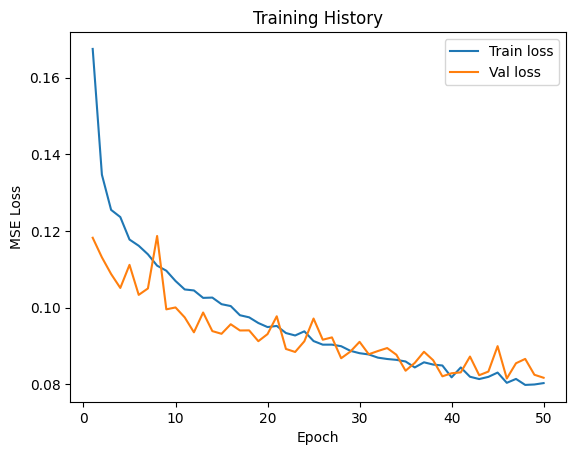

In [50]:
# Plot training loss
plt.plot(range(1, EPOCHS + 1), history['loss'], label='Train loss')
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training History')
plt.show()

Evaluate Model

In [51]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_batch.numpy())

y_pred_scaled = np.vstack(all_preds)
y_test_scaled_np = np.vstack(all_targets)

# Convert back to real AQI units
y_pred      = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled_np)

# Metrics
mse     = np.mean((y_pred - y_test_real) ** 2)
mae_real = np.mean(np.abs(y_pred - y_test_real))
r2      = r2_score(y_test_real, y_pred)

print(f'Loss (MSE)           : {mse:.4f}')
print(f'Real MAE in AQI units: {mae_real:.2f}')
print(f'R² Score             : {r2:.4f}')

Loss (MSE)           : 51.8460
Real MAE in AQI units: 4.55
R² Score             : 0.9152


In [ ]:
# Compare predictions vs actual

print(f"{'#':<5} {'Predicted':>12} {'Actual':>12} {'Difference':>12}")
print('-' * 45)
for i in range(10):
    diff = abs(y_pred[i][0] - y_test_real[i][0])
    print(f"{i+1:<5} {y_pred[i][0]:>12.2f} {y_test_real[i][0]:>12.2f} {diff:>12.2f}")

#        Predicted       Actual   Difference
---------------------------------------------
1            31.32        32.40         1.08
2            69.81        70.32         0.51
3            28.23        27.60         0.63
4            34.42        32.90         1.52
5            17.79        26.70         8.91
6            27.30        25.71         1.59
7            20.67        19.60         1.07
8            56.93        60.98         4.05
9            32.76        32.00         0.76
10           19.42        18.80         0.62


Check Model with Custom Input


In [53]:
def predict_aqi(input_dict: dict) -> float:
    """Scale input, run inference, and return real AQI value."""
    df_input = pd.DataFrame([input_dict])
    scaled   = scaler_X.transform(df_input)
    tensor   = torch.tensor(scaled, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        pred_scaled = model(tensor).cpu().numpy()
    return scaler_y.inverse_transform(pred_scaled)[0][0]


new_input = {
    'CO': 98.0, 'NO2': 2.55, 'SO2': 0.9, 'O3': 58.0,
    'PM2.5': 3.8, 'PM10': 5.5, 'Temperature': 2.64,
    'Humidity': 18.87, 'Wind Speed': 16.16,
    'hour': 12, 'day': 2, 'month': 1,
    'City_Cairo': 0, 'City_Dubai': 0,
    'City_London': 0, 'City_New York': 0, 'City_Sydney': 0,
}

print(f'Predicted AQI: {predict_aqi(new_input):.2f}')

Predicted AQI: 23.60


In [54]:
# City-wise AQI predictions
base = {
    'CO': 292.0, 'NO2': 30.15, 'SO2': 1.10, 'O3': 23.0,
    'PM2.5': 11.1, 'PM10': 15.8, 'Temperature': 17.67,
    'Humidity': 59.35, 'Wind Speed': 13.76,
    'hour': 0, 'day': 1, 'month': 1,
}

cities = {
    'Brasilia' : [0, 0, 0, 0, 0],
    'Cairo'    : [1, 0, 0, 0, 0],
    'Dubai'    : [0, 1, 0, 0, 0],
    'London'   : [0, 0, 1, 0, 0],
    'New York' : [0, 0, 0, 1, 0],
    'Sydney'   : [0, 0, 0, 0, 1],
}

print('=' * 40)
print('  City-wise AQI Predictions')
print('=' * 40)

for city, flags in cities.items():
    inp = {**base,
           'City_Cairo'   : flags[0],
           'City_Dubai'   : flags[1],
           'City_London'  : flags[2],
           'City_New York': flags[3],
           'City_Sydney'  : flags[4]}
    aqi = predict_aqi(inp)
    print(f'  {city:<12} → AQI: {aqi:.2f}')

  City-wise AQI Predictions
  Brasilia     → AQI: 19.17
  Cairo        → AQI: 53.45
  Dubai        → AQI: 36.45
  London       → AQI: 20.95
  New York     → AQI: 35.82
  Sydney       → AQI: 22.65
